# **Customer Churn Prediction using Machine Learning**

 Dataset Extraction

In [ ]:
import zipfile
with zipfile.ZipFile('/content/archive.zip','r') as zip_ref:zip_ref.extractall('/content/dataset')

Verify Extracted Files

In [ ]:
import os
os.listdir('/content/dataset')

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset

In [ ]:
df = pd.read_csv('/content/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Step 3: View Data

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 4: Understand Dataset

Number of rows and columns

In [ ]:
df.shape


(7043, 21)

check column names

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Check data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Step 5: Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Step 6: Data Cleaning

In [ ]:
df.drop('customerID',axis=1,inplace=True)

# Step 7: Convert Text to Numbers

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])

# Step 8: Exploratory Data Analysis

How many customers left?

Graph shows:

Churn = 0(stayed)
Churn = 1(left)

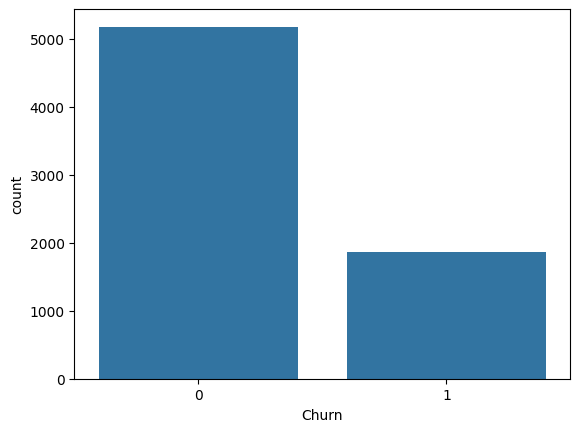

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()

Monthly Charges Distribution

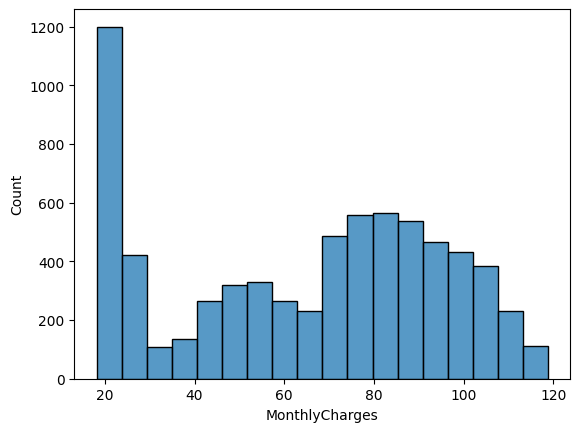

In [ ]:
sns.histplot(df['MonthlyCharges'])
plt.show()

Correlation Heatmap

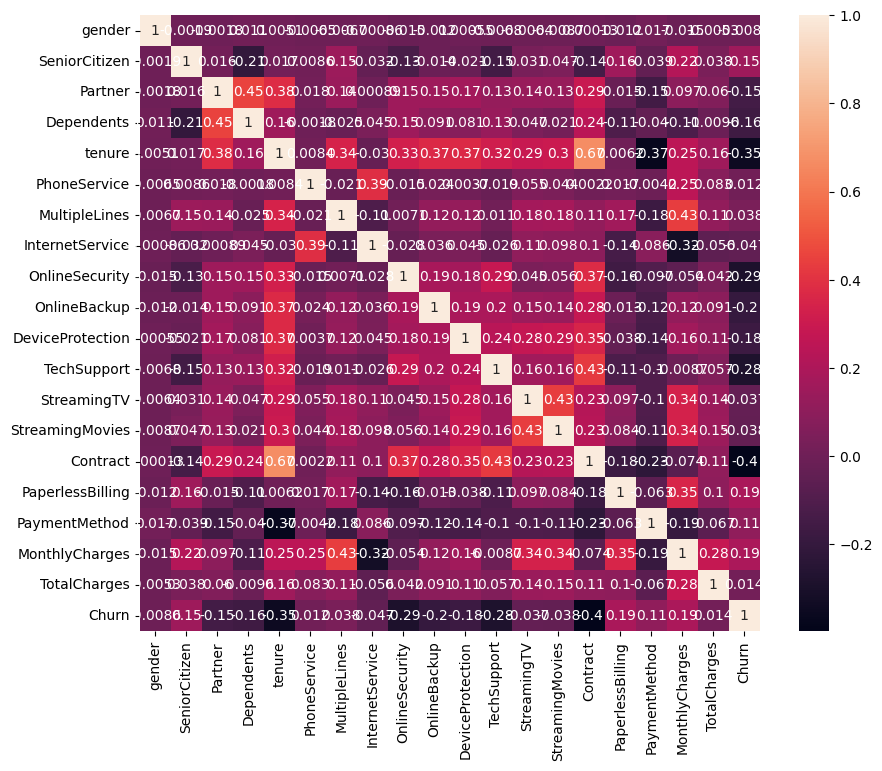

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

# Step 9: Create Features and Target

X= Inputs

y= Output

In [ ]:
X= df.drop('Churn',axis=1)
y= df['Churn']


# Step 10: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

 Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 11: Train Model

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

# Step 12: Predict

In [ ]:
y_pred=model.predict(X_test)


# Step 13: Check Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8133427963094393

# Step 14: Confusion Matrix

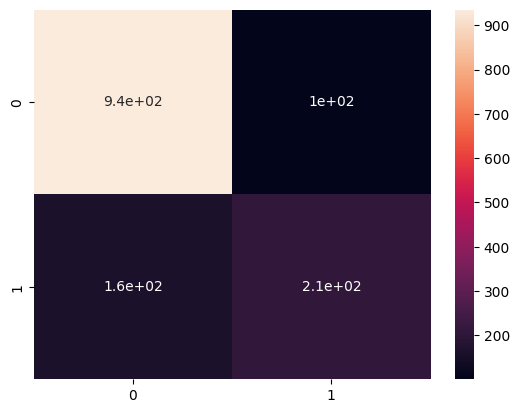

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

# Step 15: Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



# Step 16: Feature Importance using Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

<Axes: >

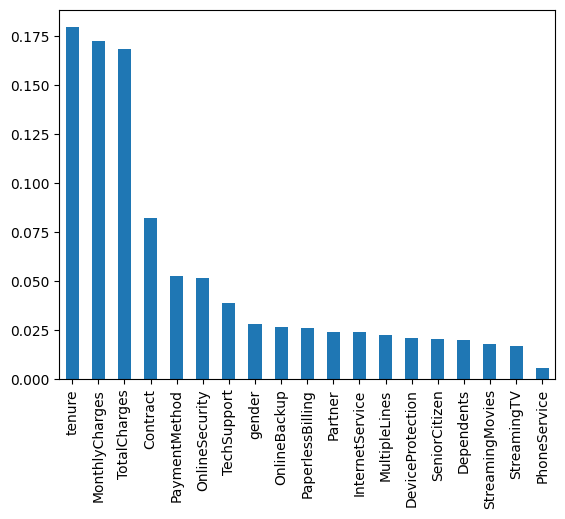

In [ ]:
importance = rf.feature_importances_
pd.Series(
    importance,
    index=X.columns
).sort_values(
    ascending=False
).plot(kind='bar')

#  Business Conclusions
## Key Findings


* Customers with month_to_month contracts have a higher churn rate.
* Customers with higher monthly charges are more likely to leave the company.
* Customers with longer tenure tend to stay with the company.



## Bussiness Recommendations


* Offer discounts and loyalty programs to customers with month_to_month contracts.
* Provide special retention offers to customers showing signs of churn.

* Encourage customers to switch to longer-term contracts.
* Improve customer engagement and support services to increase retension.

# Project Outcome
A machine learning model was developed to predict customer churn using customer demographic and service usage data.The model can help businesses identify customers at risk of leaving and take proactive actions to improve customer retension.











